In [1]:
import sys
import sklearn
import imblearn

print("Python executable:", sys.executable)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)



Python executable: /Users/davinagreen/anaconda3/bin/python
scikit-learn: 1.2.2
imbalanced-learn: 0.12.3


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. 读取数据
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']

# 2. 划分训练/验证集（20%做验证）
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. 训练基线随机森林
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_baseline.fit(X_train, y_train)

# 4. 在验证集上评估
y_val_pred = rf_baseline.predict(X_val)

print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

f1_macro = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro-average F1 Score: {f1_macro:.4f}")


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00        13
           4       0.58      0.24      0.34        46
           5       0.79      1.00      0.88       875
           6       0.91      0.85      0.88       106
           7       0.00      0.00      0.00        21
           8       0.70      0.77      0.73        98
           9       0.00      0.00      0.00         5
          10       0.49      0.91      0.64       208
          11       1.00      0.08      0.15        12
          12       0.38      0.49      0.43        88
          13       0.00      0.00      0.00        12
          14       0.00      0.00      0.00        52
          15       0.00      0.00      0.00         5
          16       0.00      0.00      0.

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [2]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Replace with your actual CSV filenames
X = pd.read_csv('X_train_cleaned.csv')  # your cleaned feature data
y = pd.read_csv('y_train_cleaned.csv')  # your cleaned labels

# If y_train_cleaned.csv is a DataFrame with a column name like 'label', select it:
y = y['label']


# 2. Train/Validation Split

# Create a validation set (20% of training data).
# 'stratify' ensures the class distribution is preserved in each split.
X_train, X_val, y_train, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


# 3. Model Training: Random Forest Baseline

# Initialize a simple baseline Random Forest
rf_baseline = RandomForestClassifier(
    n_estimators=100,  # default number of trees
    random_state=42    # for reproducibility
)

# Train on the training split
rf_baseline.fit(X_train, y_train)


# 4. Model Evaluation (Validation Set)

# Predict on validation set
y_val_pred = rf_baseline.predict(X_val)

# Print classification metrics
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred))

# Confusion matrix to see where misclassifications occur
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

# (Optional) Compute specific F1 score variant
f1_macro = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro-average F1 Score: {f1_macro:.4f}")


cv_scores = cross_val_score(rf_baseline, X_train, y_train,
                            scoring='f1_macro', cv=5)

print("5-Fold Cross-Validation Macro-average F1 Score: {:.4f}".format(cv_scores.mean()))


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00        13
           4       0.58      0.24      0.34        46
           5       0.79      1.00      0.88       875
           6       0.91      0.85      0.88       106
           7       0.00      0.00      0.00        21
           8       0.70      0.77      0.73        98
           9       0.00      0.00      0.00         5
          10       0.49      0.91      0.64       208
          11       1.00      0.08      0.15        12
          12       0.38      0.49      0.43        88
          13       0.00      0.00      0.00        12
          14       0.00      0.00      0.00        52
          15       0.00      0.00      0.00         5
          16       0.00      0.00      0.

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


5-Fold Cross-Validation Macro-average F1 Score: 0.2057


In [3]:

import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score




# 3. Cost-Sensitive Random Forest Model

# Initialize the Random Forest with cost-sensitive adjustments
rf_cost_sensitive = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    random_state=42,         # For reproducibility
    class_weight="balanced"  # Adjusts class weights inversely to class frequencies
)

# Train the model on the training split
rf_cost_sensitive.fit(X_train, y_train)


# 4. Evaluation on the Validation Set

# Predict on the validation set
y_val_pred = rf_cost_sensitive.predict(X_val)

# Print the detailed classification report (includes precision, recall, f1, and support)
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred))

# Print the confusion matrix for the hold-out validation set
print("Confusion Matrix (Validation Set):")
print(confusion_matrix(y_val, y_val_pred))

# Compute the macro-average F1 score on the validation set
f1_macro_val = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro-average F1 Score (Validation): {f1_macro_val:.4f}")


# 5. 5-Fold Cross-Validation on the Training Set

# Perform 5-fold cross-validation and calculate the macro-average F1 score
cv_scores = cross_val_score(
    rf_cost_sensitive,
    X_train,
    y_train,
    scoring='f1_macro',
    cv=5
)
print("5-Fold Cross-Validation Macro-average F1 Score: {:.4f}".format(cv_scores.mean()))


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       1.00      0.08      0.14        13
           4       0.64      0.20      0.30        46
           5       0.71      1.00      0.83       875
           6       0.91      0.78      0.84       106
           7       1.00      0.05      0.09        21
           8       0.74      0.71      0.73        98
           9       0.00      0.00      0.00         5
          10       0.50      0.86      0.63       208
          11       1.00      0.08      0.15        12
          12       0.45      0.33      0.38        88
          13       0.00      0.00      0.00        12
          14       0.00      0.00      0.00        52
          15       0.67      0.40      0.50         5
          16       0.00      0.00      0.

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


5-Fold Cross-Validation Macro-average F1 Score: 0.2134


In [4]:
import sklearn
print("scikit‑learn version:", sklearn.__version__)


scikit‑learn version: 1.2.2


In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from imblearn.over_sampling import ADASYN

# 假设 X_train, X_val, y_train, y_val 已经事先定义好

# -------------------------------
# 2. ADASYN 重采样 + 单次验证集评估
# -------------------------------

# Replace with your actual CSV filenames
X = pd.read_csv('X_train_cleaned.csv')  # your cleaned feature data
y = pd.read_csv('y_train_cleaned.csv')  # your cleaned labels

# If y_train_cleaned.csv is a DataFrame with a column name like 'label', select it:
y = y['label']


# 2. Train/Validation Split

# Create a validation set (20% of training data).
# 'stratify' ensures the class distribution is preserved in each split.
X_train, X_val, y_train, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

adasyn = ADASYN(random_state=42, n_neighbors=2)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

rf_adasyn = RandomForestClassifier(n_estimators=100, random_state=42)
rf_adasyn.fit(X_train_res, y_train_res)

y_val_pred = rf_adasyn.predict(X_val)

print("Classification Report (RF + ADASYN on Hold-Out Validation Set):")
print(classification_report(y_val, y_val_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))
print("Macro-average F1 Score:", f1_score(y_val, y_val_pred, average="macro"))


Classification Report (RF + ADASYN on Hold-Out Validation Set):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.50      0.23      0.32        13
           4       0.43      0.43      0.43        46
           5       0.86      0.98      0.92       875
           6       0.91      0.92      0.92       106
           7       0.67      0.19      0.30        21
           8       0.69      0.81      0.74        98
           9       0.00      0.00      0.00         5
          10       0.58      0.85      0.69       208
          11       0.65      0.92      0.76        12
          12       0.34      0.43      0.38        88
          13       0.00      0.00      0.00        12
          14       0.17      0.02      0.03        52
          15       0.71      1.00      0.83         5
          16     

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline



import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Assume X_train, X_val, y_train, y_val have been defined

# -------------------------------
# 2. SMOTE and Single Validation Set Evaluation
# -------------------------------
# Resample the training data using SMOTE with a lowered k_neighbors
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Initialize and train the Random Forest on the SMOTE-balanced data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

# Predict on the original hold-out validation set
y_val_pred_smote = rf_smote.predict(X_val)

# Output evaluation metrics on the validation set
print("Classification Report (Random Forest with SMOTE on Hold-Out Validation Set):")
print(classification_report(y_val, y_val_pred_smote))
print("Confusion Matrix (Validation Set):")
print(confusion_matrix(y_val, y_val_pred_smote))
print("Macro-average F1 Score (Validation Set):", f1_score(y_val, y_val_pred_smote, average="macro"))

# -------------------------------
# 3. 5-Fold Cross-Validation Using a Pipeline with SMOTE
# -------------------------------
# Create a pipeline to apply SMOTE (with k_neighbors=2) and then train the Random Forest
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42, k_neighbors=2)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Perform 5-fold cross-validation using macro-average F1 score as the metric
cv_scores_smote = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring='f1_macro',
    cv=3,
    verbose=1
)

print("3-Fold Cross-Validation Macro-average F1 Score (SMOTE Pipeline): {:.4f}".format(cv_scores_smote.mean()))


Classification Report (Random Forest with SMOTE on Hold-Out Validation Set):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.50      0.15      0.24        13
           4       0.58      0.48      0.52        46
           5       0.87      0.97      0.92       875
           6       0.88      0.92      0.90       106
           7       0.86      0.29      0.43        21
           8       0.66      0.74      0.70        98
           9       0.00      0.00      0.00         5
          10       0.61      0.86      0.71       208
          11       0.50      0.58      0.54        12
          12       0.40      0.48      0.44        88
          13       0.00      0.00      0.00        12
          14       0.14      0.02      0.03        52
          15       0.80      0.80      0.80         5
    

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


3-Fold Cross-Validation Macro-average F1 Score (SMOTE Pipeline): 0.3587


ModuleNotFoundError: No module named 'lightgbm'

In [11]:
!pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [13]:
import sys
print(sys.executable)


/Users/davinagreen/anaconda3/bin/python


In [14]:
conda install -c conda-forge lightgbm


Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
doneecting package metadata (repodata.json): - 
doneing environment: / 

## Package Plan ##

  environment location: /Users/davinagreen/anaconda3

  added / updated specs:
    - lightgbm


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    lightgbm-4.6.0             |  py311h313beb8_0         5.1 MB
    openssl-3.5.0              |       h81ee809_0         2.9 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         8.0 MB

The following NEW packages will be INSTALLED:

  lightgbm           pkgs/main/osx-arm64::lightgbm-4.6.0-py311h313beb8_0 

The following packages will be UPDATED:

  openssl              pkgs/main::openssl-3.0.16-h02f6b3c_0 --> conda-forge::openssl-3.5.0-h81ee809_0 



lightgbm-4.6.0       | 5.1 MB    |                                 

In [21]:
import pandas as pd
import numpy as np

# 导入 imblearn 的 Pipeline 和 SMOTE，用于构建包含 SMOTE 的流水线
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 导入各个分类器以及集成器
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# 数据拆分和评价指标
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 导入 joblib 的 Memory 用于缓存中间结果以加速流水线
from joblib import Memory

# ---------------------------
# 1. 数据加载与预处理
# ---------------------------
# 读取已清洗数据：X_train_cleaned.csv 保存特征，y_train_cleaned.csv 保存标签
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')
# 假设标签列名称为 "label"，将 y 转换为 1D Series
y = y['label']

# 按 80% / 20% 划分为训练集和验证集，并通过 stratify=y 保持各类别比例
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------
# 2. 定义缓存目录，用于加速流水线中重复的计算
# ---------------------------
memory = Memory(location='./cache_dir', verbose=0)

# ---------------------------
# 3. 定义包含 SMOTE 与 Cost-Sensitive 的基础模型流水线（不使用 SVC）
# ---------------------------
# (1) Random Forest 流水线
pipeline_rf = Pipeline(steps=[
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, 
                                  class_weight="balanced", n_jobs=-1))
], memory=memory)

# (2) 逻辑回归 流水线
pipeline_lr = Pipeline(steps=[
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('lr', LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42, 
                                class_weight="balanced", n_jobs=-1))
], memory=memory)

# (3) LightGBM 流水线
pipeline_lgbm = Pipeline(steps=[
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('lgbm', lgb.LGBMClassifier(random_state=42, class_weight="balanced", n_jobs=-1))
], memory=memory)

# ---------------------------
# 4. 构建基于 Voting 的集成模型（仅使用上述三种模型）
# ---------------------------
voting_clf = VotingClassifier(
    estimators=[
        ('rf', pipeline_rf),
        ('lr', pipeline_lr),
        ('lgbm', pipeline_lgbm)
    ],
    voting='soft'  # 使用软投票，即利用预测概率进行加权平均
)

# 使用训练集拟合 Voting 集成模型
voting_clf.fit(X_train, y_train)

# ---------------------------
# 5. 构建基于 Stacking 的自定义集成模型（不使用内部交叉验证）
# ---------------------------
# 分别在训练集上对各基础模型进行拟合（流水线内部的 SMOTE 同时拟合）
pipeline_rf.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)
pipeline_lgbm.fit(X_train, y_train)

# 对训练集生成 meta 特征（各模型的预测概率）
meta_train_rf = pipeline_rf.predict_proba(X_train)
meta_train_lr = pipeline_lr.predict_proba(X_train)
meta_train_lgbm = pipeline_lgbm.predict_proba(X_train)
# 拼接各模型的预测概率，形成 meta 特征矩阵（列数=三个模型预测概率之和）
X_meta_train = np.hstack((meta_train_rf, meta_train_lr, meta_train_lgbm))

# 对验证集生成 meta 特征
meta_val_rf = pipeline_rf.predict_proba(X_val)
meta_val_lr = pipeline_lr.predict_proba(X_val)
meta_val_lgbm = pipeline_lgbm.predict_proba(X_val)
X_meta_val = np.hstack((meta_val_rf, meta_val_lr, meta_val_lgbm))

# 用逻辑回归作为元模型（final_estimator），并设置 cost-sensitive 参数
meta_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, 
                                class_weight="balanced", n_jobs=-1)
meta_model.fit(X_meta_train, y_train)

# 用元模型预测验证集
y_val_pred_stacking = meta_model.predict(X_meta_val)

# ---------------------------
# 6. 模型评估
# ---------------------------
# 评估 Voting Ensemble 模型
print("=== Voting Ensemble Classification Report ===")
print(classification_report(y_val, voting_clf.predict(X_val), zero_division=0))
print("Voting Ensemble Confusion Matrix:")
print(confusion_matrix(y_val, voting_clf.predict(X_val)))

# 评估 Stacking Ensemble 模型
print("\n=== Stacking Ensemble Classification Report ===")
print(classification_report(y_val, y_val_pred_stacking, zero_division=0))
print("Stacking Ensemble Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_stacking))


/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065936 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 97916, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightG

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084706 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 97916, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightG

In [25]:
import pandas as pd
import numpy as np

# 导入 imblearn 的 Pipeline 以及过采样器
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN, BorderlineSMOTE

# 导入各个分类器
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

# 数据拆分和评价指标
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# 1. 数据加载与预处理
# ---------------------------
# 读取已清洗数据：X_train_cleaned.csv 保存特征，y_train_cleaned.csv 保存标签
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')
# 假设标签列名称为 "label"，将 y 转换为 1D Series
y = y['label']

# 将数据按照 80%/20% 划分为训练集和验证集，同时 stratify=y 保证各类别比例一致
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------
# 2. 基础模型流水线的构建
#    分别采用 ADASYN 和 BorderlineSMOTE 作为过采样方法，
#    同时每个模型都设置了 cost-sensitive（class_weight="balanced"）
# ---------------------------

# ---------------------------
# 采用 ADASYN 的流水线：
# ---------------------------
# (1) 随机森林流水线（使用 ADASYN）
pipeline_rf_adasyn = Pipeline(steps=[
    ('adasyn', ADASYN(random_state=42,n_neighbors=2)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1))
])
# (2) 逻辑回归流水线（使用 ADASYN）
pipeline_lr_adasyn = Pipeline(steps=[
    ('adasyn', ADASYN(random_state=42,n_neighbors=2)),
    ('lr', LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced", n_jobs=-1))
])
# (3) LightGBM流水线（使用 ADASYN）
pipeline_lgbm_adasyn = Pipeline(steps=[
    ('adasyn', ADASYN(random_state=42,n_neighbors=2)),
    ('lgbm', lgb.LGBMClassifier(random_state=42, class_weight="balanced", n_jobs=-1))
])

# ---------------------------
# 采用 Borderline-SMOTE 的流水线：
# ---------------------------
# (1) 随机森林流水线（使用 BorderlineSMOTE）
pipeline_rf_bsmote = Pipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1))
])
# (2) 逻辑回归流水线（使用 BorderlineSMOTE）
pipeline_lr_bsmote = Pipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('lr', LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced", n_jobs=-1))
])
# (3) LightGBM流水线（使用 BorderlineSMOTE）
pipeline_lgbm_bsmote = Pipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('lgbm', lgb.LGBMClassifier(random_state=42, class_weight="balanced", n_jobs=-1))
])

# ---------------------------
# 3. 构建 Stacking 集成模型（不使用内部交叉验证）
#    这里我们分别构建两套基于不同过采样方法的 Stacking 模型，
#    并用逻辑回归作为元模型。
# ---------------------------

def build_stacking_meta_features(pipelines, X_data):
    """
    输入：pipelines: 列表，每个元素是一个经过流水线（包含过采样）的基础模型；
    X_data: 用于生成预测概率的样本数据；
    输出：横向拼接后的 meta 特征矩阵。
    """
    meta_features = [pipe.predict_proba(X_data) for pipe in pipelines]
    return np.hstack(meta_features)

# 构建基于 ADASYN 的 Stacking 模型
pipelines_adasyn = [pipeline_rf_adasyn, pipeline_lr_adasyn, pipeline_lgbm_adasyn]
# 先在训练集上拟合所有流水线
for pipe in pipelines_adasyn:
    pipe.fit(X_train, y_train)

X_meta_train_adasyn = build_stacking_meta_features(pipelines_adasyn, X_train)
X_meta_val_adasyn   = build_stacking_meta_features(pipelines_adasyn, X_val)

# 用逻辑回归作为元模型，同时采用 cost-sensitive 设置
meta_model_adasyn = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", n_jobs=-1)
meta_model_adasyn.fit(X_meta_train_adasyn, y_train)
y_val_pred_stacking_adasyn = meta_model_adasyn.predict(X_meta_val_adasyn)

print("=== Stacking Ensemble with ADASYN Classification Report ===")
print(classification_report(y_val, y_val_pred_stacking_adasyn, zero_division=0))
print("Stacking Ensemble with ADASYN Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_stacking_adasyn))


# 构建基于 BorderlineSMOTE 的 Stacking 模型
pipelines_bsmote = [pipeline_rf_bsmote, pipeline_lr_bsmote, pipeline_lgbm_bsmote]
# 分别在训练集上拟合
for pipe in pipelines_bsmote:
    pipe.fit(X_train, y_train)

X_meta_train_bsmote = build_stacking_meta_features(pipelines_bsmote, X_train)
X_meta_val_bsmote   = build_stacking_meta_features(pipelines_bsmote, X_val)

meta_model_bsmote = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", n_jobs=-1)
meta_model_bsmote.fit(X_meta_train_bsmote, y_train)
y_val_pred_stacking_bsmote = meta_model_bsmote.predict(X_meta_val_bsmote)

print("\n=== Stacking Ensemble with BorderlineSMOTE Classification Report ===")
print(classification_report(y_val, y_val_pred_stacking_bsmote, zero_division=0))
print("Stacking Ensemble with BorderlineSMOTE Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_stacking_bsmote))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.184077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 97862, number of used features: 300
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightG

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.130255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 90932, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightG

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# ---------------------------
# 1. Define a Cost-Sensitive Wrapper for XGBoost
# ---------------------------
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        # Compute balanced sample weights
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# ---------------------------
# 2. Load and Split the Data
# ---------------------------
# Load features and labels.
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')
y = y['label']  # assuming label column is named 'label'
# Note: In your case, labels are 0-indexed (0 to 27)

# Split data into training (80%) and validation (20%) sets with stratification.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# ---------------------------
# 3. Build Oversampling Pipelines with Cost-Sensitive Models
# ---------------------------
# Pipeline 1: ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

# Pipeline 2: BorderlineSMOTE + Random Forest
pipe_rf = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('rf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

# Pipeline 3: ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

# Pipeline 4: BorderlineSMOTE + CostSensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
                n_estimators=100,
                objective='multi:softprob',
                num_class=num_classes,
                use_label_encoder=False,
                eval_metric='mlogloss',
                random_state=42))
])

# ---------------------------
# 4. Ensemble Voting: Combine the Pipelines
# ---------------------------
ensemble = VotingClassifier(
    estimators=[
        ('lr', pipe_lr),
        ('rf', pipe_rf),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'  # soft voting, uses predicted probabilities
)

# ---------------------------
# 5. Train the Ensemble Model
# ---------------------------
ensemble.fit(X_train, y_train)

# ---------------------------
# 6. Make Predictions and Evaluate
# ---------------------------
y_pred = ensemble.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print("Ensemble Validation Accuracy:", acc)
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred))


Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from s

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:56:39] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Validation Accuracy: 0.7853457172342622
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.57      0.31      0.40        13
           4       0.60      0.70      0.65        46
           5       0.91      0.97      0.94       875
           6       0.91      0.95      0.93       106
           7       0.62      0.38      0.47        21
           8       0.76      0.79      0.77        98
           9       0.00      0.00      0.00         5
          10       0.70      0.85      0.77       208
          11       0.64      0.75      0.69        12
          12       0.47      0.52      0.50        88
          13       0.00      0.00      0.00        12
          14       0.23      0.06      0.09        52
          15       0.80      0.80      0.80         5


/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# ---------------------------
# 1. Define a Cost-Sensitive Wrapper for XGBoost
# ---------------------------
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# ---------------------------
# 2. Load and Split the Data
# ---------------------------
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']  # assuming label column is named 'label'
# Labels are assumed to be 0-indexed (0 to 27)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# ---------------------------
# 3. Build Base Pipelines with Oversampling and Cost-Sensitive Models
# ---------------------------
# Pipeline 1: ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

# Pipeline 2: BorderlineSMOTE + Random Forest
pipe_rf = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('rf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

# Pipeline 3: ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

# Pipeline 4: BorderlineSMOTE + CostSensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
                n_estimators=100,
                objective='multi:softprob',
                num_class=num_classes,
                eval_metric='mlogloss',
                random_state=42))
])

# ---------------------------
# 4. Manually Build a Stacking Ensemble Without CV
# ---------------------------
# Train each base pipeline on the full training set.
print("Training base pipelines...")
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_lgbm.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)

# Generate meta-features (predicted probabilities) from each pipeline on the training set.
print("Generating meta-features on training data...")
meta_train_lr = pipe_lr.predict_proba(X_train)
meta_train_rf = pipe_rf.predict_proba(X_train)
meta_train_lgbm = pipe_lgbm.predict_proba(X_train)
meta_train_xgb = pipe_xgb.predict_proba(X_train)

# Concatenate meta-features horizontally.
meta_train = np.hstack([meta_train_lr, meta_train_rf, meta_train_lgbm, meta_train_xgb])

# Train a final meta-model on these meta-features.
print("Training meta-model...")
final_estimator = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
final_estimator.fit(meta_train, y_train)

# Generate meta-features for the validation set.
print("Generating meta-features on validation data...")
meta_val_lr = pipe_lr.predict_proba(X_val)
meta_val_rf = pipe_rf.predict_proba(X_val)
meta_val_lgbm = pipe_lgbm.predict_proba(X_val)
meta_val_xgb = pipe_xgb.predict_proba(X_val)
meta_val = np.hstack([meta_val_lr, meta_val_rf, meta_val_lgbm, meta_val_xgb])

# Use the meta-model to make final predictions.
y_pred = final_estimator.predict(meta_val)

# Evaluate the stacked ensemble.
acc = accuracy_score(y_val, y_pred)
print("Manual Stacked Ensemble Validation Accuracy:", acc)
print("Manual Stacked Ensemble Classification Report:")
print(classification_report(y_val, y_pred))


Number of classes: 28
Training base pipelines...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Average nearest neighbor distances for class 0:
[12.6378561  13.7254834  15.91921462 11.98076182 16.16411676 14.84186137
 12.1623699  15.23460146 14.92893497 13.83227399 19.88798058 15.14499178
 15.03076352 13.16176392 13.92645309 13.87700287 12.39479664]


Matplotlib is building the font cache; this may take a moment.


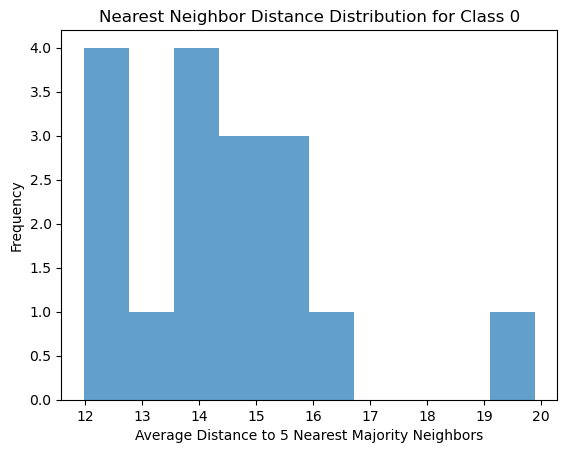

In [10]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Convert your DataFrame X to a NumPy array if needed.
X_array = X.values
y_array = y.values

# Let’s define your majority classes – for instance, assume majority classes are those with high counts.
# Alternatively, you might set a threshold (here, classes other than the rare ones).
rare_classes = [0, 1, 2, 9, 16, 22]
majority_idx = [i for i, label in enumerate(y_array) if label not in rare_classes]
minority_idx = [i for i, label in enumerate(y_array) if label in rare_classes]

# Create arrays for majority samples and for a particular rare class.
# For demonstration, let's analyze class 0.
target_class = 0
target_idx = [i for i, label in enumerate(y_array) if label == target_class]
X_target = X_array[target_idx]
X_majority = X_array[[i for i in range(len(y_array)) if y_array[i] not in rare_classes]]  # all majority samples

# Fit a NearestNeighbors model on the majority samples.
nbrs = NearestNeighbors(n_neighbors=5)  # e.g., consider 5 nearest neighbors
nbrs.fit(X_majority)

# For each sample in the target minority class, compute the distances to its 5 nearest majority neighbors.
distances, indices = nbrs.kneighbors(X_target)

# Compute average distance for each sample.
avg_distances = distances.mean(axis=1)
print(f"Average nearest neighbor distances for class {target_class}:")
print(avg_distances)

# You can also visualize a histogram of these distances.
import matplotlib.pyplot as plt
plt.hist(avg_distances, bins=10, alpha=0.7)
plt.title(f'Nearest Neighbor Distance Distribution for Class {target_class}')
plt.xlabel('Average Distance to 5 Nearest Majority Neighbors')
plt.ylabel('Frequency')
plt.show()


Class 0:
  Count: 17 samples
  Mean average distance: 14.40
  Median average distance: 13.93

Class 1:
  Count: 7 samples
  Mean average distance: 16.51
  Median average distance: 16.62

Class 2:
  Count: 7 samples
  Mean average distance: 14.82
  Median average distance: 13.95

Class 9:
  Count: 25 samples
  Mean average distance: 13.90
  Median average distance: 12.45

Class 16:
  Count: 6 samples
  Mean average distance: 15.93
  Median average distance: 16.20

Class 22:
  Count: 6 samples
  Mean average distance: 16.67
  Median average distance: 16.18



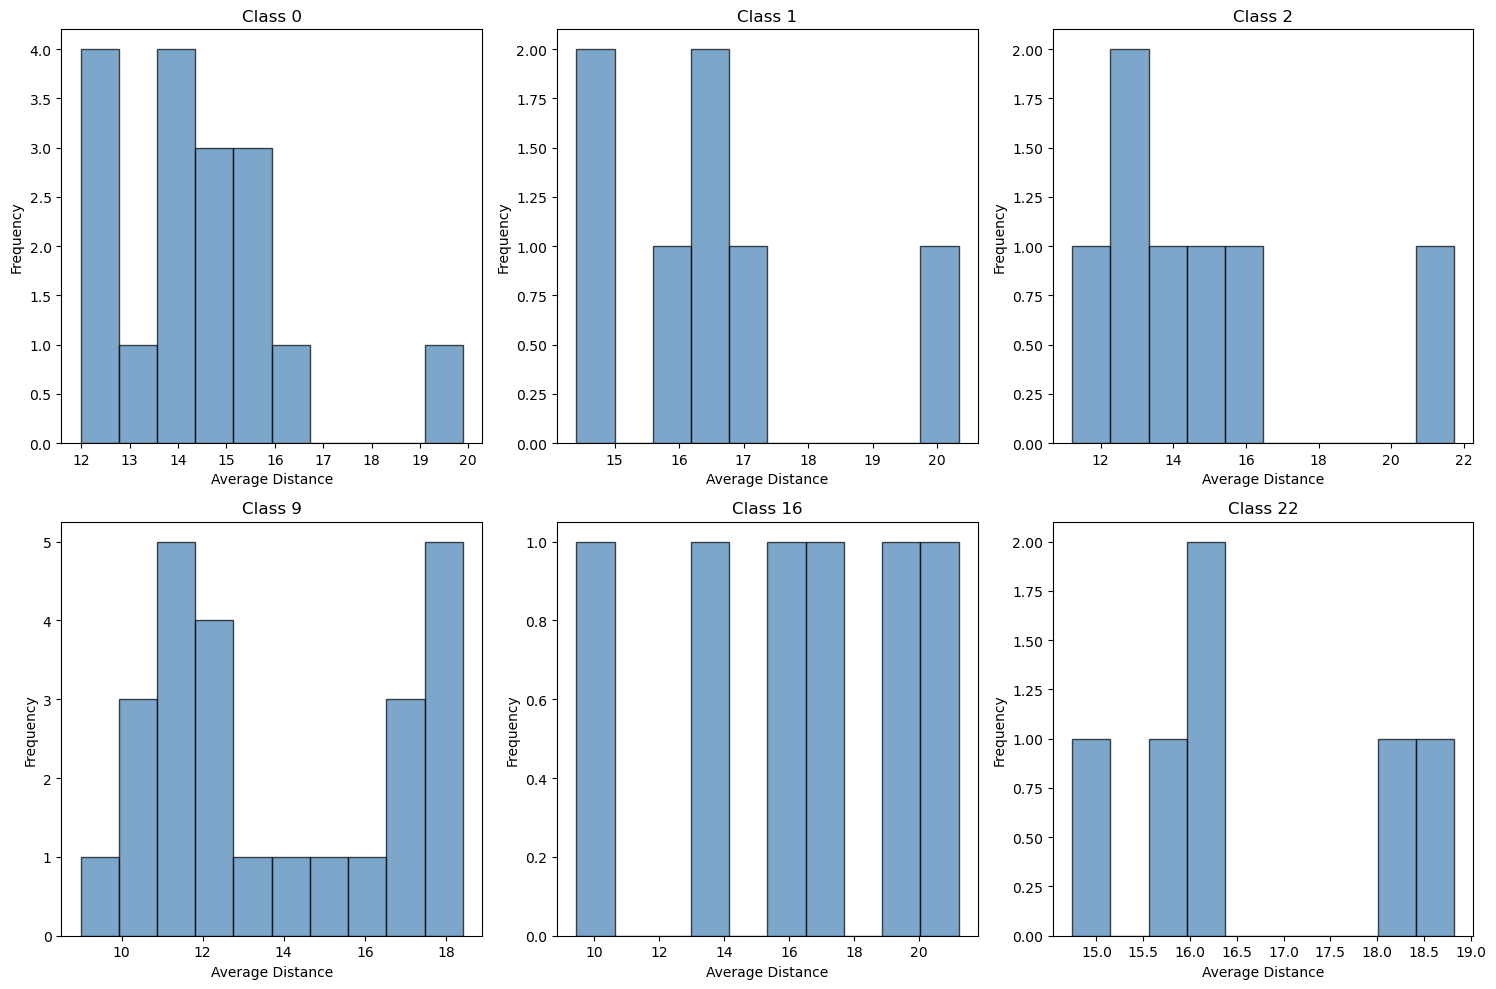

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ---------------------------
# 1. Load Data
# ---------------------------
# Replace the file paths with your actual CSV file locations if needed
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']

# Convert the DataFrame to numpy arrays for efficiency
X_array = X.values
y_array = y.values

# ---------------------------
# 2. Define the Rare Classes
# ---------------------------
rare_classes = [0, 1, 2, 9, 16, 22]

# ---------------------------
# 3. Compute Average Distances for Each Rare Class
# ---------------------------
# This dictionary will store arrays of average distances (to 5 nearest majority neighbors) per rare class.
rare_avg_dists = {}

# We will use 5 nearest neighbors
k = 5

for cls in rare_classes:
    # Get indices of all samples that belong to this rare class
    target_idx = [i for i, label in enumerate(y_array) if label == cls]
    # For "majority" we take samples that do NOT belong to any rare class.
    majority_idx = [i for i, label in enumerate(y_array) if label not in rare_classes]
    
    # If there are no samples for this class, skip (should not happen in your case)
    if len(target_idx) == 0:
        continue
    
    X_target = X_array[target_idx]
    X_majority = X_array[majority_idx]
    
    # Fit a k-nearest neighbors model on the majority samples
    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs.fit(X_majority)
    
    # For each target (rare) sample, find the k nearest neighbors among the majority samples.
    distances, _ = nbrs.kneighbors(X_target)
    # Compute the average distance for each rare sample (across its 5 neighbors)
    avg_dist = distances.mean(axis=1)
    rare_avg_dists[cls] = avg_dist

    # Print summary statistics for this rare class
    print(f"Class {cls}:")
    print(f"  Count: {len(avg_dist)} samples")
    print(f"  Mean average distance: {np.mean(avg_dist):.2f}")
    print(f"  Median average distance: {np.median(avg_dist):.2f}\n")

# ---------------------------
# 4. Plot Histograms for Each Rare Class
# ---------------------------
# Create one subplot per rare class
num_rare = len(rare_avg_dists)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, cls in enumerate(rare_classes):
    if cls in rare_avg_dists:
        axes[i].hist(rare_avg_dists[cls], bins=10, alpha=0.7, color='steelblue', edgecolor='black')
        axes[i].set_title(f'Class {cls}')
        axes[i].set_xlabel('Average Distance')
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()
